<a href="https://colab.research.google.com/github/joodw1/ML_Labs/blob/main/Data_Quality_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

## 1. Load Dataset

In [2]:
df = pd.read_csv("index_1.csv")

In [3]:
df.head()

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


## 2. Data Quality Assessment
### 2.1 Check Data Types
Data types must match the real meaning of each column.
For example:
- `date` and `datetime` should be datetime
- `money` should be numeric

In [4]:
df.dtypes

,0
date,object
datetime,object
cash_type,object
card,object
money,float64
coffee_name,object


In [5]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')

In [6]:
df.dtypes

,0
date,datetime64[ns]
datetime,datetime64[ns]
cash_type,object
card,object
money,float64
coffee_name,object


In [7]:
# `money` is already numeric in this dataset
df['money'] = pd.to_numeric(df['money'], errors='coerce')

In [8]:
df.dtypes

,0
date,datetime64[ns]
datetime,datetime64[ns]
cash_type,object
card,object
money,float64
coffee_name,object


In [9]:
df.dtypes

,0
date,datetime64[ns]
datetime,datetime64[ns]
cash_type,object
card,object
money,float64
coffee_name,object


We observe that some columns may be stored as object type. Converting `date` and `datetime` to proper datetime format helps with time-based analysis, while making sure `money` is numeric allows statistical calculations.

Now the date-related columns are correctly stored as datetime, and `money` is numeric. This allows us to perform time analysis and numerical preprocessing correctly.

## 3. Handling Missing Values
### 3.1 Detect Missing Values
Missing values reduce data quality and can affect model performance.

In [10]:
df.isna()

,date,datetime,cash_type,card,money,coffee_name
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
3631,False,False,False,False,False,False
3632,False,False,False,False,False,False
3633,False,False,False,False,False,False
3634,False,False,False,False,False,False


In [11]:
df.isna().sum()

,0
date,0
datetime,0
cash_type,0
card,89
money,0
coffee_name,0


The output shows whether any column contains missing values.
If all values are zero, the dataset is complete.
If any column contains missing values, we must handle them.

### 3.2 Demonstration: Introduce Artificial Missing Values
### Why?
Since our dataset may have very few or no missing values, we introduce artificial ones **for learning purposes**.

We will run:

`df2.loc[0:5, 'money'] = np.nan`

This sets the first six rows of the `money` column to missing values so we can demonstrate different handling strategies.

In [12]:
df2 = df.copy()
df2.loc[0:5, 'money'] = np.nan

In [13]:
df2.isna().sum()

,0
date,0
datetime,0
cash_type,0
card,89
money,6
coffee_name,0


Now the `money` column contains missing values.

In [14]:
df2.head(10)

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,NaN,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,NaN,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,NaN,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,NaN,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,NaN,Latte
5,2024-03-01,2024-03-01 15:39:47.726,card,ANON-0000-0000-0005,NaN,Americano with Milk
6,2024-03-01,2024-03-01 16:19:02.756,card,ANON-0000-0000-0006,38.7,Hot Chocolate
7,2024-03-01,2024-03-01 18:39:03.580,card,ANON-0000-0000-0007,33.8,Americano with Milk
8,2024-03-01,2024-03-01 19:22:01.762,card,ANON-0000-0000-0008,38.7,Cocoa
9,2024-03-01,2024-03-01 19:23:15.887,card,ANON-0000-0000-0008,33.8,Americano with Milk


### Strategy 1: Remove Records
This strategy removes records containing missing data.
It works well if the number of missing rows is small.

In [15]:
df_remove = df2.dropna()

In [16]:
print('df with NaN: ',df2.shape)
print('df without NaN: ',df_remove.shape)

df with NaN:  (3636, 6)
df without NaN:  (3541, 6)


In [17]:
df_remove.isna().sum()

,0
date,0
datetime,0
cash_type,0
card,0
money,0
coffee_name,0


The dataset now has fewer rows.
If only a small portion of data was missing, this method is acceptable.

However, removing too many rows can reduce model performance.

### Strategy 2: Mean Imputation

_(illustration omitted)_

The mean represents the average value.
It is commonly used for normally distributed data.

In [18]:
df_mean = df2.copy()
df_mean['money'] = df_mean['money'].fillna(df_mean['money'].mean())

In [19]:
df_mean.head(10)

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,31.739416,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,31.739416,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,31.739416,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,31.739416,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,31.739416,Latte
5,2024-03-01,2024-03-01 15:39:47.726,card,ANON-0000-0000-0005,31.739416,Americano with Milk
6,2024-03-01,2024-03-01 16:19:02.756,card,ANON-0000-0000-0006,38.700000,Hot Chocolate
7,2024-03-01,2024-03-01 18:39:03.580,card,ANON-0000-0000-0007,33.800000,Americano with Milk
8,2024-03-01,2024-03-01 19:22:01.762,card,ANON-0000-0000-0008,38.700000,Cocoa
9,2024-03-01,2024-03-01 19:23:15.887,card,ANON-0000-0000-0008,33.800000,Americano with Milk


Missing values are now replaced with the average sales amount. This preserves dataset size but may reduce variability. Mean imputation is sensitive to outliers.

### Strategy 3: Median Imputation
_(illustration omitted)_
The median is more robust to outliers than the mean. It is preferred for skewed data.

In [20]:
df_median = df2.copy()
df_median['money'] = df_median['money'].fillna(df_median['money'].median())

In [21]:
df_median.head(10)

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,32.82,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,32.82,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,32.82,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,32.82,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,32.82,Latte
5,2024-03-01,2024-03-01 15:39:47.726,card,ANON-0000-0000-0005,32.82,Americano with Milk
6,2024-03-01,2024-03-01 16:19:02.756,card,ANON-0000-0000-0006,38.70,Hot Chocolate
7,2024-03-01,2024-03-01 18:39:03.580,card,ANON-0000-0000-0007,33.80,Americano with Milk
8,2024-03-01,2024-03-01 19:22:01.762,card,ANON-0000-0000-0008,38.70,Cocoa
9,2024-03-01,2024-03-01 19:23:15.887,card,ANON-0000-0000-0008,33.80,Americano with Milk


Missing values are replaced with the middle value.
This approach is safer when data contains extreme values.

## 4. Handling Outliers
Outliers are extreme values that can distort models. We will detect outliers in the `money` column using the IQR method.

_(illustration omitted)_

In [22]:
import matplotlib.pyplot as plt

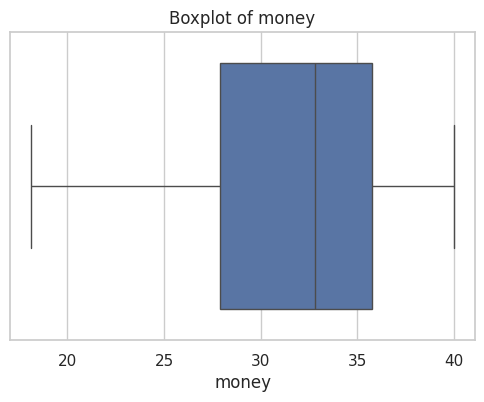

In [23]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['money'])
plt.title('Boxplot of money')
plt.show()

Points outside the whiskers represent potential outliers. These extreme transaction amounts may influence model predictions.

### Detect Outliers using IQR
**Method: Interquartile Range (IQR)**

The IQR method defines outliers as values outside:

`Q1 - 1.5×IQR`  and  `Q3 + 1.5×IQR`

In [24]:
Q1 = df['money'].quantile(0.25)
Q3 = df['money'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['money'] < lower) | (df['money'] > upper)]
outliers.head(15)

,date,datetime,cash_type,card,money,coffee_name


The output displays records considered extreme based on statistical boundaries.
These may be valid high-value transactions or potential data errors.

### Remove Outliers
We remove values outside the acceptable range.

In [25]:
df_no_outliers = df[(df['money'] >= lower) & (df['money'] <= upper)]

print('df with outliers: ', df.shape)
print('df without outliers: ', df_no_outliers.shape)

df with outliers:  (3636, 6)
df without outliers:  (3636, 6)


The dataset size is slightly reduced. Removing outliers reduces distortion but may also remove important rare events.

#### Important Note on Removing Outliers
Not all outliers are errors.
Some extreme values may represent real-world events, such as unusually expensive orders or multiple coffees purchased together.
Before removing outliers, always consider the business meaning of the data.

### Capping Outliers (Percentile Method)
Instead of removing outliers, we replace extreme values with percentile limits.

_(illustration omitted)_

In [26]:
lower_cap = df['money'].quantile(0.05)
upper_cap = df['money'].quantile(0.95)

df_capped = df.copy()
df_capped['money'] = df_capped['money'].clip(lower_cap, upper_cap)

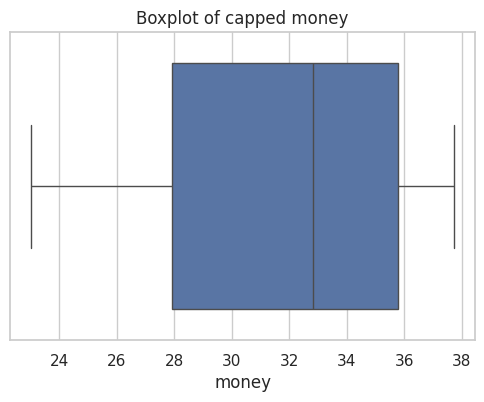

In [27]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_capped['money'])
plt.title('Boxplot of capped money')
plt.show()

## 5. Data Transformation – Normalization
Normalization scales numerical features to a similar range.
Here we use:
- `money` = transaction amount
- `hour` = hour extracted from the transaction timestamp

### Min-Max Normalization
Min-Max normalization rescales numerical values to a fixed range, usually between 0 and 1.

_(illustration omitted)_

In [28]:
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
df['hour'] = df['datetime'].dt.hour
df[['money','hour']].head()

,money,hour
0,38.7,10
1,38.7,12
2,38.7,12
3,28.9,13
4,38.7,13


In [29]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df[['money', 'hour']].copy()

df_scaled[['money', 'hour']] = scaler.fit_transform(df_scaled)

df_scaled.head()

,money,hour
0,0.940585,0.2500
1,0.940585,0.3750
2,0.940585,0.3750
3,0.492687,0.4375
4,0.940585,0.4375


After applying Min-Max normalization, all numerical values are scaled to the range between 0 and 1.

The smallest value in each feature becomes 0, and the largest becomes 1.
All other values are proportionally mapped between these two limits.

Importantly, normalization does NOT change the relative relationships between data points.
If one transaction originally had higher sales amount than another, it will still have a higher normalized value.

### Z-Score Normalization
Z-score standardization transforms the data so that:
- The mean of each feature becomes 0
- The standard deviation becomes 1

Here we standardize `money` and `hour`.

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = df[['money', 'hour']].copy()

df_standardized[['money', 'hour']] = scaler.fit_transform(df_standardized)

df_standardized.head()

,money,hour
0,1.413456,-0.985722
1,1.413456,-0.512575
2,1.413456,-0.512575
3,-0.578718,-0.276002
4,1.413456,-0.276002


After standardization, the numerical features are centered around 0.
Values above the original mean become **positive**, and values below the mean become **negative**.

The standard deviation of each feature becomes approximately 1, meaning the spread of the data is standardized.

This transformation is especially useful for:
- Linear regression
- Support Vector Machines (SVM)
- PCA

Because these models assume features are centered and scaled similarly.

## Check Correlation Before Applying PCA
We check whether the numerical features are correlated. If features are strongly correlated, they contain overlapping information.

- **Correlation close to 1** → strong positive linear relationship
- **Correlation close to -1** → strong negative linear relationship
- **Correlation close to 0** → weak or no linear relationship

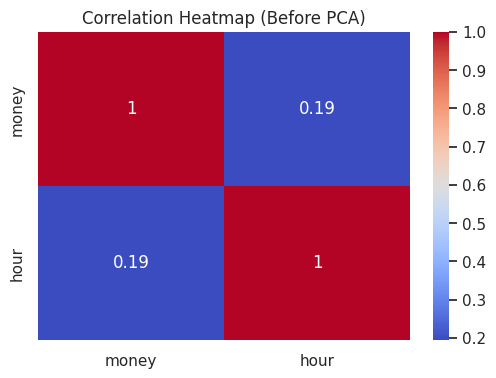

In [31]:
plt.figure(figsize=(6,4))
sns.heatmap(df_standardized[['money','hour']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap (Before PCA)')
plt.show()

The heatmap shows the correlation between `money` and `hour`.
If the correlation is weak, PCA may not provide a strong reduction benefit, but it is still useful as a demonstration of the technique.

## 6. Data Reduction – Principal Component Analysis (PCA)
Principal Component Analysis (PCA) is a dimensionality reduction technique.

Instead of working directly with the original features, PCA creates new features called **principal components**.

Here we apply PCA to the standardized features `money` and `hour`.

### Visual Intuition
Imagine we have two features:
- X1 = money
- X2 = hour

If the points show a directional pattern, PCA can rotate the space and summarize the data using fewer components.

In [32]:
from sklearn.decomposition import PCA

X = df_standardized[['money', 'hour']]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print('Explained Variance Ratio:', pca.explained_variance_ratio_)

Explained Variance Ratio: [0.59738495 0.40261505]


The `Explained Variance Ratio` indicates how much of the total information (variance) is captured by each principal component.

For example:
- If PC1 explains 85% of the variance, it means that one new feature already summarizes most of the dataset's information.
- If PC1 and PC2 together explain nearly 100%, then very little information is lost.

When most of the variance is captured by fewer components, dimensionality reduction is considered effective.

This helps simplify models, reduce computational cost, and sometimes improve generalization performance.

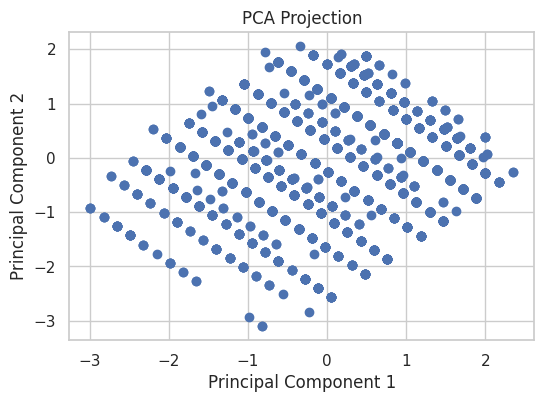

In [33]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

Each point in this plot represents one coffee transaction.
The axes now represent Principal Component 1 and Principal Component 2, not the original features.
This helps us view the structure of the standardized data in a transformed space.